# ColBERTv2 vs Bi-Encoder Retrieval Benchmark

End-to-end pipeline: data loading → chunking → NER classification → bi-encoder retrieval → ColBERTv2 retrieval → evaluation → visualization.

All results are written to a single JSON log file. Evaluation and visualization read exclusively from that log.

In [1]:
import os, sys

# Ensure project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import yaml
from src.profiler import Profiler

# Load config
with open("configs/experiment_config.yaml", "r") as f:
    config = yaml.safe_load(f)

print("Config loaded:")
for section, values in config.items():
    print(f"  {section}: {values}")

Config loaded:
  corpus: {'target_size': 500, 'local_corpus_cache': 'data/corpus_cache.parquet', 'seed': 42}
  chunking: {'strategy': 'paragraph', 'sentence_window_size': 3, 'sentence_window_stride': 2, 'adaptive_min_words': 80, 'adaptive_max_words': 160}
  queries: {'sample_size_per_group': 150, 'seed': 42}
  retrieval: {'k_values': [1, 5, 10, 20]}
  models: {'biencoder': 'sentence-transformers/all-MiniLM-L6-v2', 'colbert': 'colbert-ir/colbertv2.0'}
  colbert: {'bsize': 32}
  paths: {'results_dir': 'results', 'faiss_index_dir': 'results/faiss_index', 'colbert_index_dir': 'results/colbert_index', 'json_log': 'results/benchmark_log.json', 'charts_dir': 'results/charts', 'csv_output': 'results/summary_statistics.csv'}
  spacy: {'model': 'en_core_web_sm', 'entity_threshold': 2}


## 1. Data Pipeline

Load KILT NQ, build reduced corpus, chunk, classify queries by NER, sample balanced groups, extract ground-truth.

In [2]:
from src.data_pipeline import run_data_pipeline
import gc

profiler = Profiler(config=config)
pipeline_out = run_data_pipeline(config, profiler)

chunks = pipeline_out["chunks"]
sampled_queries = pipeline_out["sampled_queries"]
del pipeline_out
gc.collect()

print(f"Total chunks: {len(chunks)}")
print(f"Sampled queries: {len(sampled_queries)}")
print(f"  single-entity: {sum(1 for q in sampled_queries if q['entity_group'] == 'single-entity')}")
print(f"  multi-entity:  {sum(1 for q in sampled_queries if q['entity_group'] == 'multi-entity')}")

c:\Users\Cosmo\Documents\GitHub\1508-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/kilt_tasks' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Streaming KILT Wikipedia (need 415 gold + 85 distractors)...
    Scanned 100000 pages, gold found: 11/415, distractors: 85/85
    Scanned 200000 pages, gold found: 16/415, distractors: 85/85
    Scanned 300000 pages, gold found: 23/415, distractors: 85/85
    Scanned 400000 pages, gold found: 31/415, distractors: 85/85
    Scanned 500000 pages, gold found: 37/415, distractors: 85/85
    Scanned 600000 pages, gold found: 45/415, distractors: 85/85
    Scanned 700000 pages, gold found: 53/415, distractors: 85/85
    Scanned 800000 pages, gold found: 57/415, distractors: 85/85
    Scanned 900000 pages, gold found: 67/415, distractors: 85/85
    Scanned 1000000 pages, gold found: 75/415, distractors: 85/85
    Scanned 1100000 pages, gold found: 80/415, distractors: 85/85
    Scanned 1200000 pages, gold found: 86/415, distractors: 85/85
    Scanned 1300000 pages, gold found: 95/415, distractors: 85/85
    Scanned 1400000 pages, gold found: 99/415, distractors: 85/85
    Scanned 1500000 pa

## 2. Bi-Encoder Retrieval

Encode chunks with MiniLM, build FAISS index, retrieve top-k for each query.

In [3]:
from src.biencoder_retrieval import run_biencoder_retrieval

run_biencoder_retrieval(chunks, sampled_queries, config, profiler)
print("Bi-encoder retrieval complete.")
print(f"  Sample query recall@10: {sampled_queries[0].get('biencoder_recall_at_k', {}).get('10', 'N/A')}")

Batches: 100%|██████████| 47/47 [00:04<00:00, 11.34it/s]


Bi-encoder retrieval complete.
  Sample query recall@10: 0.0


## 3. ColBERTv2 Retrieval

Index chunks with RAGatouille ColBERTv2, retrieve top-k with late interaction scoring.

In [ ]:
from src.colbert_retrieval import run_colbert_retrieval

run_colbert_retrieval(chunks, sampled_queries, config, profiler)
print("ColBERTv2 retrieval complete.")
print(f"  Sample query recall@10: {sampled_queries[0].get('colbert_recall_at_k', {}).get('10', 'N/A')}")

---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 06, 18:21:56] #> Creating directory results\colbert_index\colbert\indexes/colbert_benchmark 


[Apr 06, 18:21:57] [0] 		 #> Encoding 11901 passages..


c:\Users\Cosmo\Documents\GitHub\1508-project\.venv\Lib\site-packages\colbert\utils\amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


[Apr 06, 18:22:15] [0] 		 avg_doclen_est = 45.523738861083984 	 len(local_sample) = 11,901
[Apr 06, 18:22:15] [0] 		 Creating 8,192 partitions.
[Apr 06, 18:22:15] [0] 		 *Estimated* 541,778 embeddings.
[Apr 06, 18:22:15] [0] 		 #> Saving the indexing plan to results\colbert_index\colbert\indexes/colbert_benchmark\plan.json ..
PyTorch-based indexing did not succeed with error: CUDA out of memory. Tried to allocate 15.71 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 6.64 GiB is allocated by PyTorch, and 12.00 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables) ! Reverting to using FAISS and attempting again...
________________________________________________________________________________
WARNING! You have a 

0it [00:00, ?it/s]

[Apr 06, 18:26:07] [0] 		 #> Encoding 11901 passages..


...

100%|██████████| 1/1 [00:00<00:00, 499.98it/s]

[Apr 06, 18:26:27] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 47.62it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: how long did the menendez brothers get in prison for killing their parents, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2129,  2146,  2106,  1996,  2273, 28787,  3428,  2131,
         1999,  3827,  2005,  4288,  2037,  3008,   102,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



ColBERTv2 retrieval complete.
  Sample query recall@10: 0.0


## 4. Save JSON Log & Log Per-Query Results

Write per-query results to the profiler and save the complete JSON log.

In [10]:
# Log per-query results into the profiler
for q in sampled_queries:
    record = {
        "query": q["query"],
        "entity_count": q["entity_count"],
        "entity_list": q["entity_list"],
        "entity_group": q["entity_group"],
        "ground_truth_chunk_ids": q["ground_truth_chunk_ids"],
    }
    # Bi-encoder results
    for key in ("biencoder_retrieved_ids", "biencoder_recall_at_k", "biencoder_latency_ms"):
        if key in q:
            record[key] = q[key]
    # ColBERT results
    for key in ("colbert_retrieved_ids", "colbert_recall_at_k", "colbert_latency_ms"):
        if key in q:
            record[key] = q[key]
    profiler.log_query(record)

# Store model names in metadata
profiler.data["metadata"]["models"] = config["models"]
profiler.data["metadata"]["k_values"] = config["retrieval"]["k_values"]

# Save JSON log
log_path = config["paths"]["json_log"]
profiler.save(log_path)
print(f"JSON log saved to: {log_path}")

# Verify key fields
import json
with open(log_path, "r", encoding="utf-8") as f:
    log = json.load(f)
print(f"  Stages recorded: {list(log['stages'].keys())}")
print(f"  Queries logged: {len(log['queries'])}")
print(f"  Disk sizes: {log['disk_sizes']}")
print(f"  Metadata keys: {list(log['metadata'].keys())}")

JSON log saved to: results/benchmark_log.json
  Stages recorded: ['data_loading', 'ner_classification', 'query_sampling', 'corpus_construction', 'chunking', 'biencoder_encoding', 'faiss_indexing', 'biencoder_retrieval', 'colbert_indexing', 'colbert_retrieval']
  Queries logged: 520
  Disk sizes: {'faiss_index': 18279981, 'colbert_index': 26370706}
  Metadata keys: ['timestamp', 'config', 'gpu_device', 'gpu_total_vram_bytes', 'corpus_size', 'total_chunks', 'total_queries', 'chunking', 'queries_per_group', 'colbert_index_path', 'models', 'k_values']


## 5. Evaluation

Compute Recall@k from the JSON log (reads exclusively from JSON, no recomputation).

In [11]:
from src.evaluation import run_evaluation

summary = run_evaluation(config["paths"]["json_log"])
print("Summary Statistics:")
print(summary.to_string(index=False))

Summary Statistics:
 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.072222        0.099222  0.027000
single-entity  5          0.168222        0.190889  0.022667
single-entity 10          0.213444        0.208556 -0.004889
single-entity 20          0.243333        0.232444 -0.010889
 multi-entity  1          0.074329        0.099784  0.025455
 multi-entity  5          0.208355        0.195866 -0.012489
 multi-entity 10          0.255866        0.254805 -0.001061
 multi-entity 20          0.298160        0.288528 -0.009632
      overall  1          0.073114        0.099460  0.026346
      overall  5          0.185201        0.192995  0.007793
      overall 10          0.231392        0.228123 -0.003269
      overall 20          0.266529        0.256172 -0.010357


## 6. Visualization

Generate all charts and CSV export (reads exclusively from JSON log).

In [12]:
from src.visualize import run_visualization

output_paths = run_visualization(
    log_path=config["paths"]["json_log"],
    charts_dir=config["paths"]["charts_dir"],
    csv_path=config["paths"]["csv_output"],
)

print("Generated outputs:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

Generated outputs:
  recall_bar_chart: results/charts\recall_bar_chart.png
  recall_histograms: ['results/charts\\recall_histogram_k1.png', 'results/charts\\recall_histogram_k5.png', 'results/charts\\recall_histogram_k10.png', 'results/charts\\recall_histogram_k20.png']
  latency_comparison: results/charts\latency_comparison.png
  index_size_comparison: results/charts\index_size_comparison.png
  summary_csv: results/summary_statistics.csv


## 7. Display Charts


--- recall_bar_chart ---


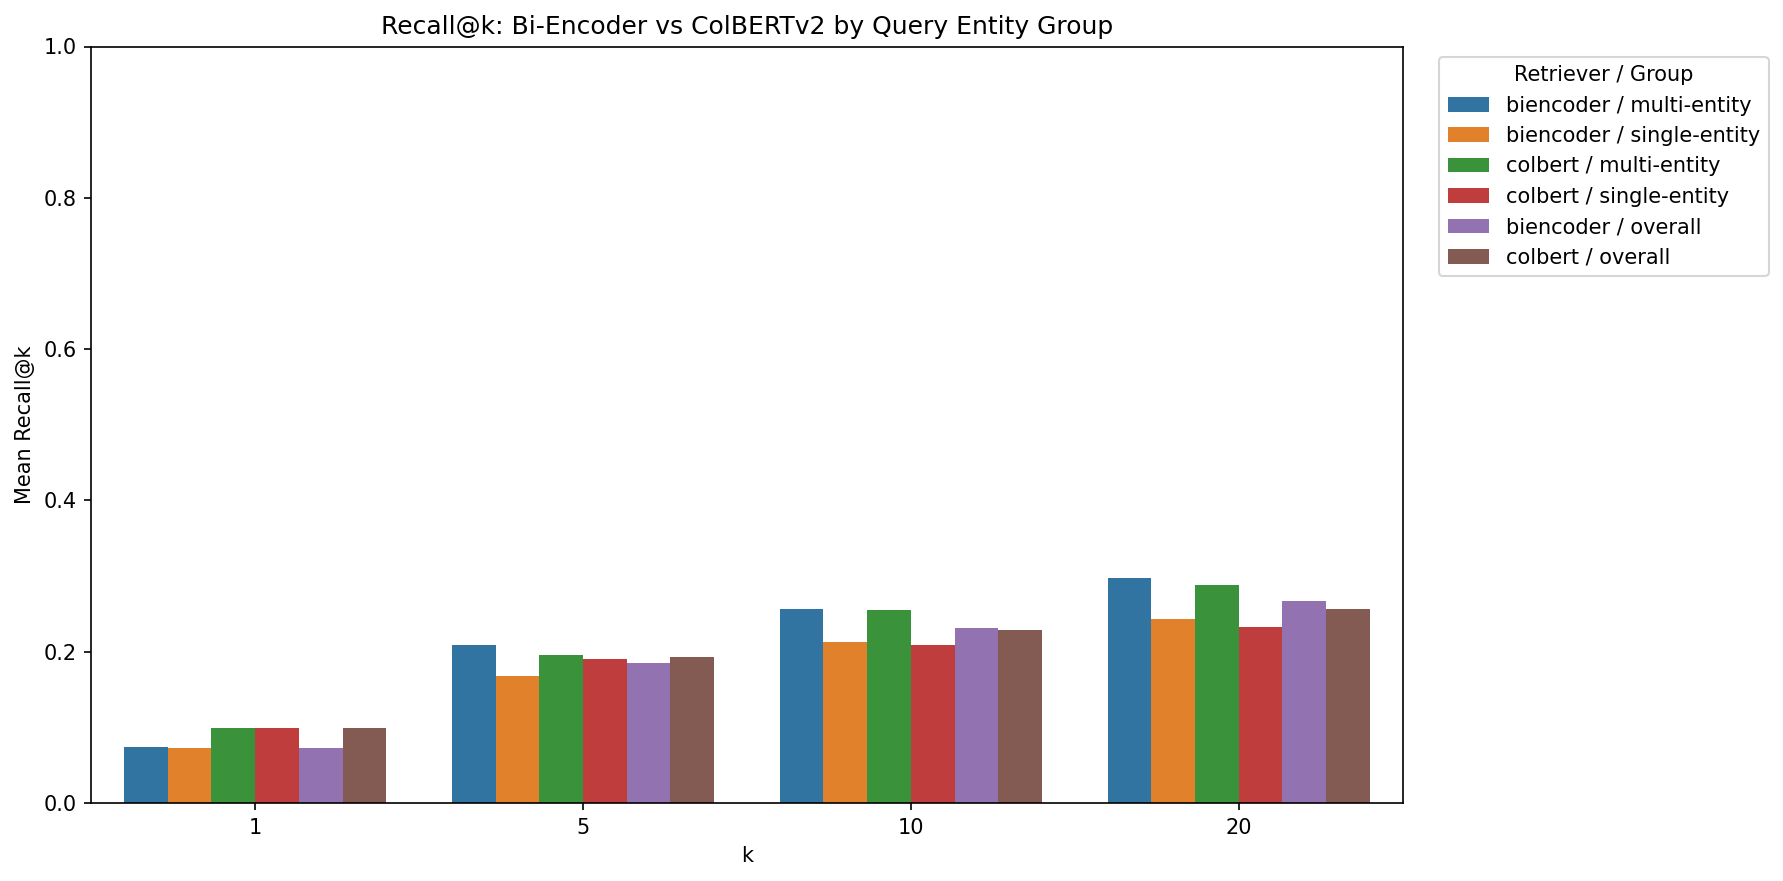


--- results/charts\recall_histogram_k1.png ---


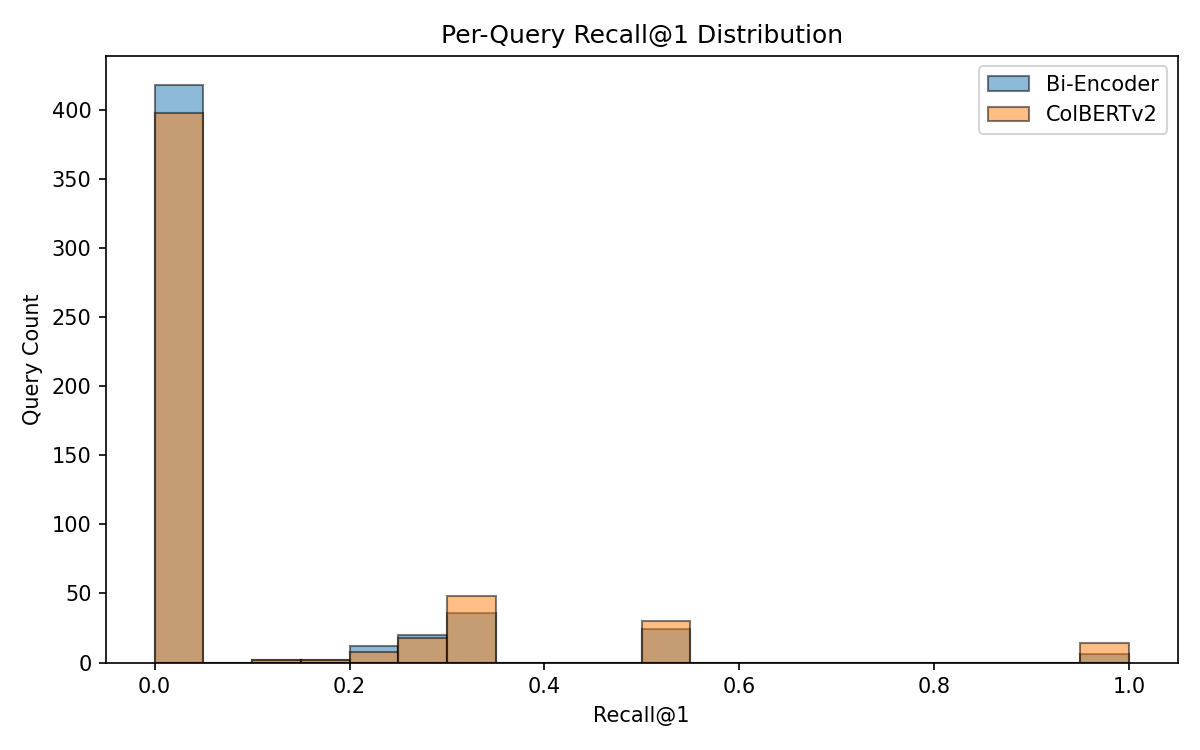


--- results/charts\recall_histogram_k5.png ---


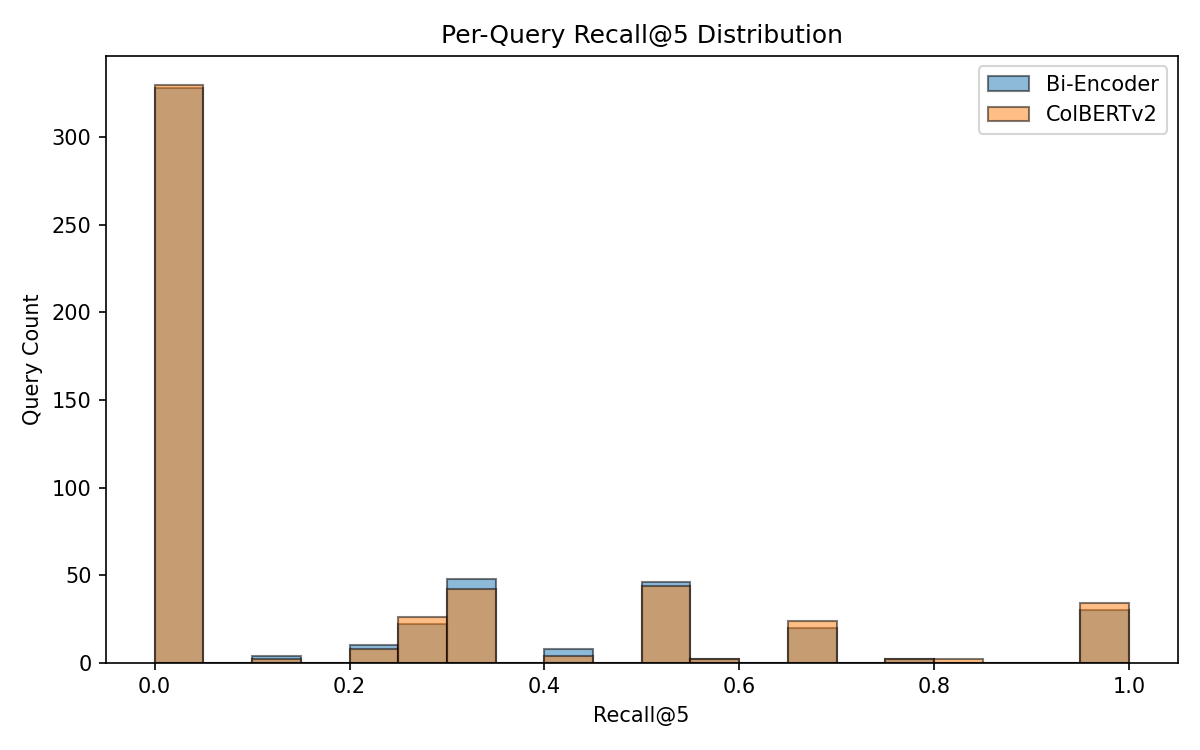


--- results/charts\recall_histogram_k10.png ---


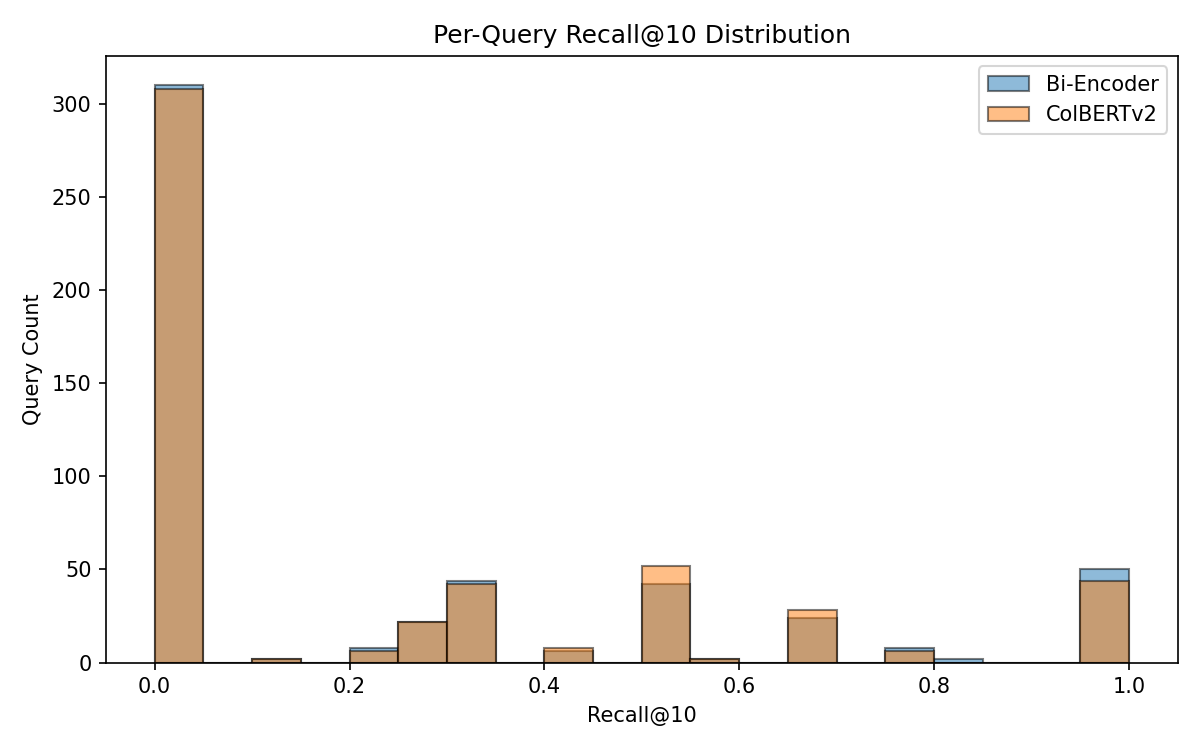


--- results/charts\recall_histogram_k20.png ---


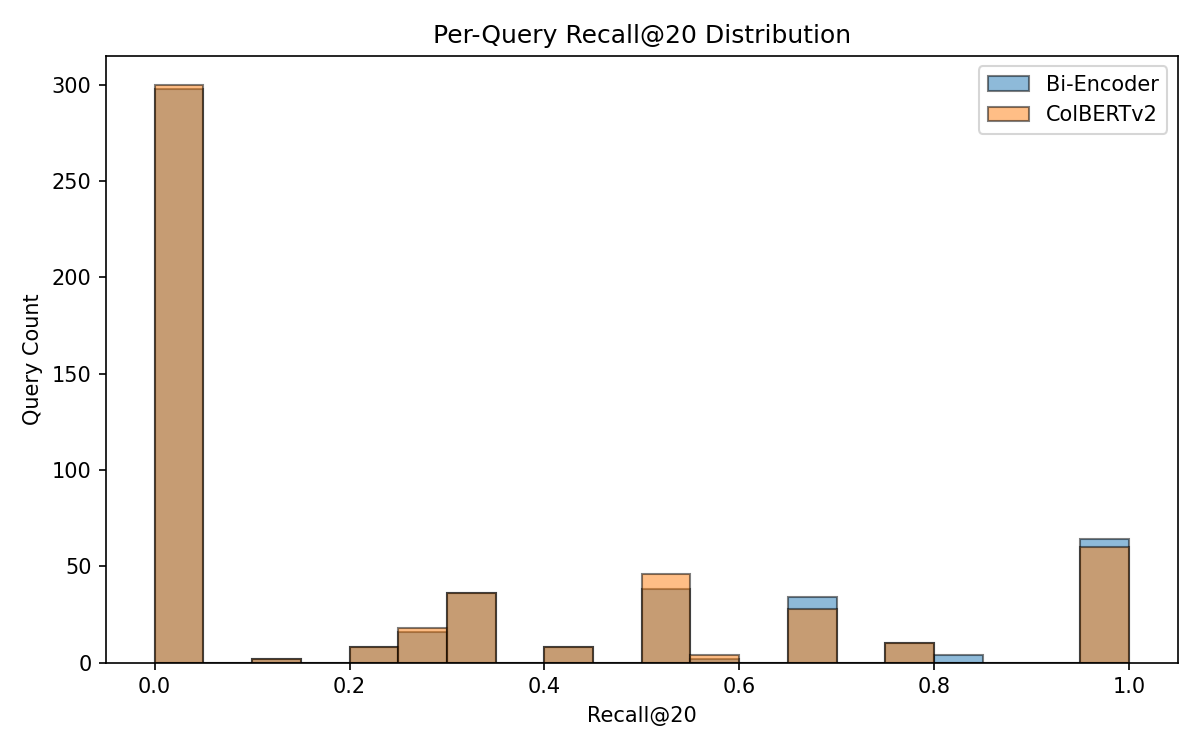


--- latency_comparison ---


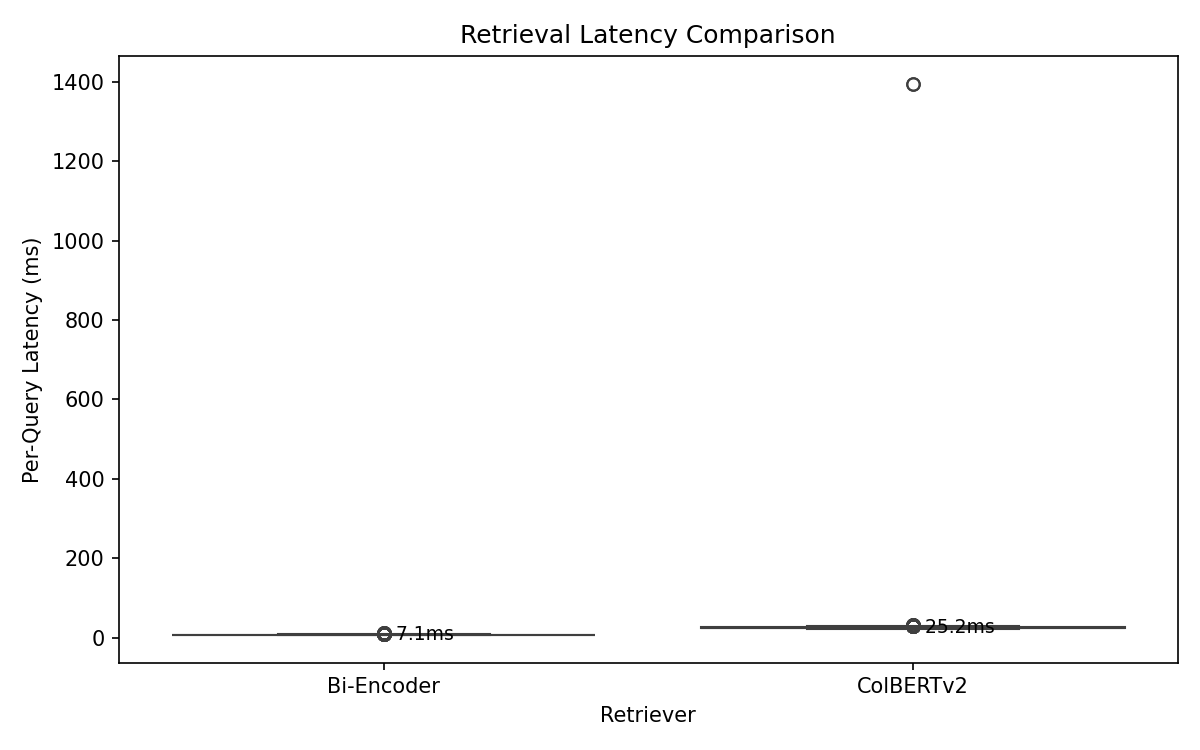


--- index_size_comparison ---


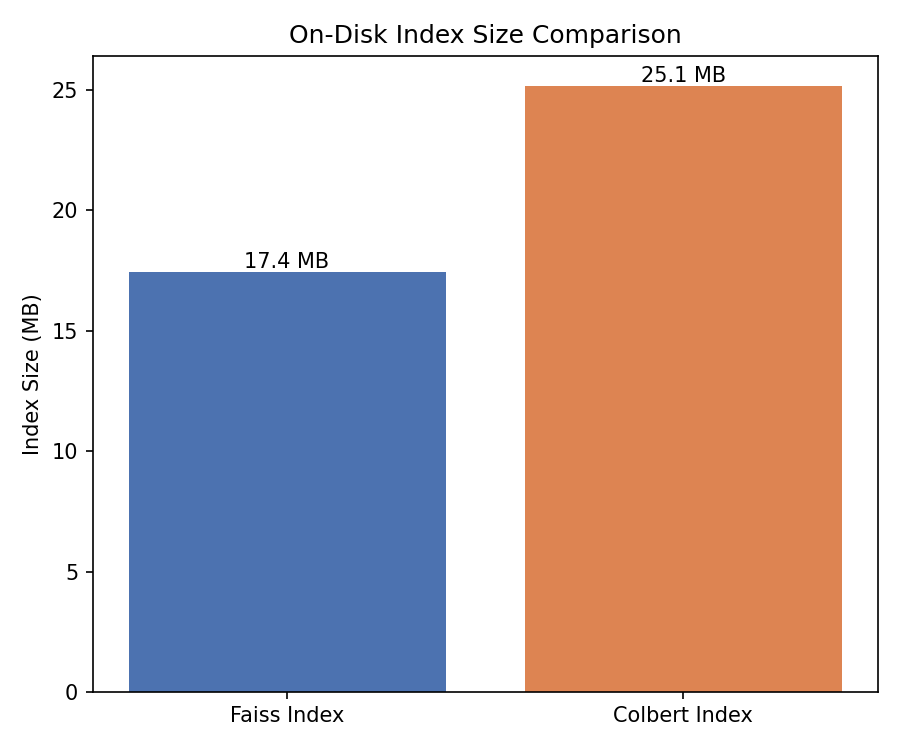

In [13]:
from IPython.display import Image, display

for name, path in output_paths.items():
    if isinstance(path, str) and path.endswith(".png"):
        print(f"\n--- {name} ---")
        display(Image(filename=path))
    elif isinstance(path, list):
        for p in path:
            print(f"\n--- {p} ---")
            display(Image(filename=p))

## 8. Profiling Summary

In [15]:
import json

with open(config["paths"]["json_log"], encoding="utf-8") as f:
    log = json.load(f)

print("=== Stage Timings ===")
for stage, info in log["stages"].items():
    vram = f", VRAM peak: {info['peak_vram_bytes']/1e9:.2f} GB" if info.get("peak_vram_bytes") else ""
    print(f"  {stage}: {info['duration_seconds']:.2f}s, RSS: {info['rss_bytes']/1e9:.2f} GB{vram}")

print(f"\n=== Disk Sizes ===")
for label, size in log["disk_sizes"].items():
    print(f"  {label}: {size/1e6:.1f} MB")

print(f"\n=== Run Metadata ===")
meta = log["metadata"]
print(f"  Timestamp: {meta['timestamp']}")
print(f"  GPU: {meta.get('gpu_device', 'None')}")
print(f"  Corpus size: {meta.get('corpus_size', 'N/A')} pages")
print(f"  Total chunks: {meta.get('total_chunks', 'N/A')}")
print(f"  Queries: {meta.get('total_queries', 'N/A')}")
print(f"  Queries per group: {meta.get('queries_per_group', 'N/A')}")

=== Stage Timings ===
  data_loading: 2.22s, RSS: 0.56 GB
  ner_classification: 6.09s, RSS: 0.60 GB
  query_sampling: 0.00s, RSS: 0.60 GB
  corpus_construction: 639.27s, RSS: 0.60 GB
  chunking: 0.10s, RSS: 0.60 GB
  biencoder_encoding: 5.42s, RSS: 1.14 GB, VRAM peak: 1.38 GB
  faiss_indexing: 0.13s, RSS: 1.14 GB, VRAM peak: 0.10 GB
  biencoder_retrieval: 1.90s, RSS: 1.09 GB, VRAM peak: 0.10 GB
  colbert_indexing: 270.93s, RSS: 1.16 GB, VRAM peak: 19.79 GB
  colbert_retrieval: 7.99s, RSS: 1.19 GB, VRAM peak: 1.55 GB

=== Disk Sizes ===
  faiss_index: 18.3 MB
  colbert_index: 26.4 MB

=== Run Metadata ===
  Timestamp: 2026-04-06T22:08:09.574914+00:00
  GPU: NVIDIA GeForce RTX 3070
  Corpus size: 224 pages
  Total chunks: 11901
  Queries: 260
  Queries per group: {'single-entity': 150, 'multi-entity': 110}
